## My algorithm in Manifold


HYBRID U-NET + RESNET MANIFOLD LEARNING
Combining U-Net compression + ResNet gradient flow

Using device: cuda

Dataset splits:
  Train: 54000 samples
  Val:   3000 samples
  Test:  3000 samples

Dataset size: 54000, Sparsity: 10% visible
Dataset size: 3000, Sparsity: 10% visible
Dataset size: 3000, Sparsity: 10% visible

Model architecture:
  Total parameters: 3,239,297
  Latent dimension: 3136 (64×7×7 spatial)
  ResNet blocks per resolution: 2

HYBRID U-NET + RESNET MANIFOLD LEARNING - TRAINING
Latent dimension: 3136 (64×7×7 spatial)
ResNet blocks per resolution: 2
Max epochs: 100, Patience: 7


/home/to247392/anaconda3/envs/manitorch/lib/python3.11/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Epoch 1/100, Batch 0, Loss: 1.6690 (Recon_x: 0.7565, Recon_s: 0.7794, Consistency: 1.3316)
Epoch 1/100, Batch 100, Loss: 0.1279 (Recon_x: 0.1095, Recon_s: 0.0126, Consistency: 0.0571)
Epoch 1/100, Batch 200, Loss: 0.1115 (Recon_x: 0.0985, Recon_s: 0.0089, Consistency: 0.0408)
Epoch 1/100, Batch 300, Loss: 0.1045 (Recon_x: 0.0928, Recon_s: 0.0078, Consistency: 0.0396)
Epoch 1/100, Batch 400, Loss: 0.0997 (Recon_x: 0.0879, Recon_s: 0.0081, Consistency: 0.0366)

Epoch 1/100 Summary:
  TRAIN - Total: 0.1351, Recon_x: 0.1079, Recon_s: 0.0203, Consistency: 0.0700
  VAL   - Total: 0.1027, Recon_x: 0.0901, Recon_s: 0.0087, Consistency: 0.0386
  ✓ NEW BEST MODEL! (Val loss: 0.1027)

Epoch 2/100, Batch 0, Loss: 0.0950 (Recon_x: 0.0851, Recon_s: 0.0061, Consistency: 0.0377)
Epoch 2/100, Batch 100, Loss: 0.1034 (Recon_x: 0.0946, Recon_s: 0.0054, Consistency: 0.0339)
Epoch 2/100, Batch 200, Loss: 0.0943 (Recon_x: 0.0858, Recon_s: 0.0060, Consistency: 0.0255)
Epoch 2/100, Batch 300, Loss: 0.0866 (Re

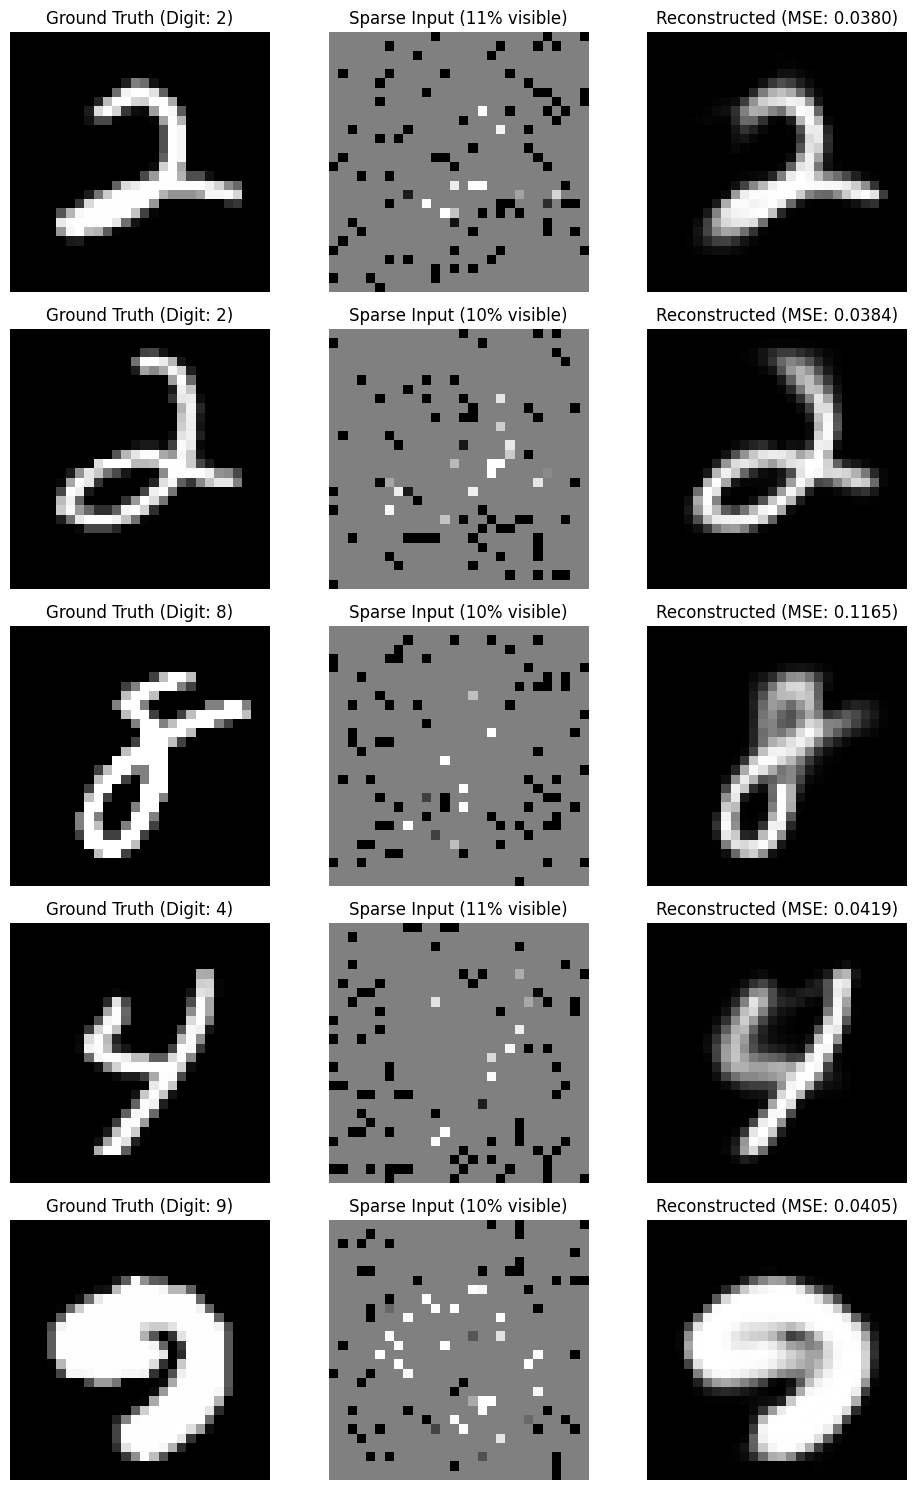


MULTI-SPARSITY EVALUATION
Testing at sparsity levels: [0.1, 0.15, 0.2, 0.25]


──────────────────────────────────────────────────────────────────────
Evaluating at ρ = 0.10 (10% visible pixels)
──────────────────────────────────────────────────────────────────────
Dataset size: 3000, Sparsity: 10% visible

Results for ρ = 0.10:
  Mean MSE:   0.053065
  Median MSE: 0.046525

──────────────────────────────────────────────────────────────────────
Evaluating at ρ = 0.15 (15% visible pixels)
──────────────────────────────────────────────────────────────────────
Dataset size: 3000, Sparsity: 15% visible

Results for ρ = 0.15:
  Mean MSE:   0.033833
  Median MSE: 0.030242

──────────────────────────────────────────────────────────────────────
Evaluating at ρ = 0.20 (20% visible pixels)
──────────────────────────────────────────────────────────────────────
Dataset size: 3000, Sparsity: 20% visible

Results for ρ = 0.20:
  Mean MSE:   0.024975
  Median MSE: 0.022386

──────────────────────────

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import numpy as np
import json

# ============================================================================
# 1. DATASET WITH CONFIGURABLE SPARSITY (UNCHANGED)
# ============================================================================

class EnhancedMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, sparsity_level=0.15):
        """
        Args:
            sparsity_level: Fraction of pixels to KEEP (0.15 = 15% visible)
        """
        self.mnist_dataset = mnist_dataset
        self.sparsity_level = sparsity_level
        print(f"Dataset size: {len(mnist_dataset)}, Sparsity: {sparsity_level:.0%} visible")
    
    def __len__(self):
        return len(self.mnist_dataset)
    
    def __getitem__(self, idx):
        full_image, digit_label = self.mnist_dataset[idx]
        
        # Create sparse measurement - KEEP sparsity_level fraction of pixels
        mask = (torch.rand_like(full_image) < self.sparsity_level).float()
        sparse_image = full_image * mask
        
        x = {'sparse_image': sparse_image, 'mask': mask}
        s = {
            'full_image': full_image,
            'digit_label': digit_label
        }
        
        return x, s

# ============================================================================
# 2. RESIDUAL BLOCKS (ResNet Component)
# ============================================================================

class ResidualBlock(nn.Module):
    """
    Residual block with pre-activation (modern ResNet design)
    Maintains spatial resolution
    """
    def __init__(self, channels):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
    
    def forward(self, x):
        residual = x
        
        # Pre-activation design
        out = F.relu(self.bn1(x))
        out = self.conv1(out)
        out = F.relu(self.bn2(out))
        out = self.conv2(out)
        
        # Add residual connection
        out = out + residual
        return out

# ============================================================================
# 3. HYBRID U-NET + RESNET ENCODERS
# ============================================================================

class HybridSparseEncoder(nn.Module):
    """
    Hybrid encoder: U-Net structure + ResNet blocks
    
    Architecture:
    - Initial conv to expand channels
    - ResBlock at each resolution for feature refinement
    - Downsample between resolutions (U-Net style)
    - Final bottleneck: 64×7×7
    """
    def __init__(self, latent_channels=64, num_res_blocks=2):
        super().__init__()
        
        # Input: 2 channels (sparse_image + mask), 28×28
        self.input_conv = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # Resolution 1: 28×28, 64 channels
        self.res_blocks_1 = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)]
        )
        
        # Downsample 1: 28×28 → 14×14
        self.down1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # Resolution 2: 14×14, 128 channels
        self.res_blocks_2 = nn.Sequential(
            *[ResidualBlock(128) for _ in range(num_res_blocks)]
        )
        
        # Downsample 2: 14×14 → 7×7
        self.down2 = nn.Sequential(
            nn.Conv2d(128, latent_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU()
        )
        
        # Resolution 3: 7×7, latent_channels (bottleneck)
        self.res_blocks_bottleneck = nn.Sequential(
            *[ResidualBlock(latent_channels) for _ in range(num_res_blocks)]
        )
        
        self.latent_channels = latent_channels
        self.num_res_blocks = num_res_blocks
    
    def forward(self, sparse_image, mask):
        x = torch.cat([sparse_image, mask], dim=1)  # (B, 2, 28, 28)
        
        x = self.input_conv(x)      # (B, 64, 28, 28)
        x = self.res_blocks_1(x)    # (B, 64, 28, 28) - ResNet refinement
        
        x = self.down1(x)            # (B, 128, 14, 14) - U-Net downsample
        x = self.res_blocks_2(x)    # (B, 128, 14, 14) - ResNet refinement
        
        x = self.down2(x)            # (B, 64, 7, 7) - U-Net downsample
        z = self.res_blocks_bottleneck(x)  # (B, 64, 7, 7) - ResNet refinement
        
        return z


class HybridFullImageEncoder(nn.Module):
    """
    Hybrid encoder for full images (same structure as sparse encoder)
    """
    def __init__(self, latent_channels=64, num_res_blocks=2):
        super().__init__()
        
        # Input: 1 channel (full_image), 28×28
        self.input_conv = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # Resolution 1: 28×28, 64 channels
        self.res_blocks_1 = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)]
        )
        
        # Downsample 1: 28×28 → 14×14
        self.down1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # Resolution 2: 14×14, 128 channels
        self.res_blocks_2 = nn.Sequential(
            *[ResidualBlock(128) for _ in range(num_res_blocks)]
        )
        
        # Downsample 2: 14×14 → 7×7
        self.down2 = nn.Sequential(
            nn.Conv2d(128, latent_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(latent_channels),
            nn.ReLU()
        )
        
        # Resolution 3: 7×7, latent_channels (bottleneck)
        self.res_blocks_bottleneck = nn.Sequential(
            *[ResidualBlock(latent_channels) for _ in range(num_res_blocks)]
        )
        
        self.latent_channels = latent_channels
        self.num_res_blocks = num_res_blocks
    
    def forward(self, full_image):
        x = self.input_conv(full_image)  # (B, 64, 28, 28)
        x = self.res_blocks_1(x)         # (B, 64, 28, 28)
        
        x = self.down1(x)                # (B, 128, 14, 14)
        x = self.res_blocks_2(x)         # (B, 128, 14, 14)
        
        x = self.down2(x)                # (B, 64, 7, 7)
        z = self.res_blocks_bottleneck(x)  # (B, 64, 7, 7)
        
        return z

# ============================================================================
# 4. HYBRID DECODER (U-Net structure + ResNet blocks)
# ============================================================================

class HybridDecoder(nn.Module):
    """
    Hybrid decoder: U-Net upsampling + ResNet refinement blocks
    """
    def __init__(self, latent_channels=64, num_res_blocks=2):
        super().__init__()
        
        # Input: latent_channels, 7×7
        
        # Resolution 1: 7×7, latent_channels (bottleneck)
        self.res_blocks_bottleneck = nn.Sequential(
            *[ResidualBlock(latent_channels) for _ in range(num_res_blocks)]
        )
        
        # Upsample 1: 7×7 → 14×14
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # Resolution 2: 14×14, 128 channels
        self.res_blocks_2 = nn.Sequential(
            *[ResidualBlock(128) for _ in range(num_res_blocks)]
        )
        
        # Upsample 2: 14×14 → 28×28
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # Resolution 3: 28×28, 64 channels
        self.res_blocks_3 = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)]
        )
        
        # Output convolution
        self.output_conv = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Tanh()
        )
    
    def forward(self, z):
        x = self.res_blocks_bottleneck(z)  # (B, 64, 7, 7)
        
        x = self.up1(x)                    # (B, 128, 14, 14)
        x = self.res_blocks_2(x)          # (B, 128, 14, 14)
        
        x = self.up2(x)                    # (B, 64, 28, 28)
        x = self.res_blocks_3(x)          # (B, 64, 28, 28)
        
        img = self.output_conv(x)          # (B, 1, 28, 28)
        return img

# ============================================================================
# 5. COMPLETE HYBRID MODEL
# ============================================================================

class HybridUNetResNetModel(nn.Module):
    """
    Hybrid U-Net + ResNet Manifold Learning Model
    
    Combines:
    - U-Net's hierarchical compression (28→14→7)
    - ResNet's residual blocks for gradient flow and refinement
    
    Benefits:
    - Better gradient flow than pure U-Net
    - More expressive features at each resolution
    - Stronger reconstruction quality
    - Still maintains compact 64×7×7 manifold
    """
    def __init__(self, latent_channels=64, num_res_blocks=2):
        super().__init__()
        self.encoder_x = HybridSparseEncoder(latent_channels, num_res_blocks)
        self.encoder_s = HybridFullImageEncoder(latent_channels, num_res_blocks)
        self.decoder = HybridDecoder(latent_channels, num_res_blocks)
        
        self.latent_channels = latent_channels
        self.num_res_blocks = num_res_blocks
        self.latent_dim = latent_channels * 7 * 7
        
    def forward(self, x, s):
        """Forward pass for both modalities"""
        sparse_image = x['sparse_image']
        mask = x['mask']
        full_image = s['full_image']
        
        # Encode both modalities to spatial latent
        z_x = self.encoder_x(sparse_image, mask)  # (B, 64, 7, 7)
        z_s = self.encoder_s(full_image)          # (B, 64, 7, 7)
        
        # Decode both
        img_recon_x = self.decoder(z_x)           # (B, 1, 28, 28)
        img_recon_s = self.decoder(z_s)           # (B, 1, 28, 28)
        
        return z_x, z_s, img_recon_x, img_recon_s

# ============================================================================
# 6. TRAINING WITH VALIDATION AND EARLY STOPPING
# ============================================================================

def train_model_with_validation(model, train_loader, val_loader, 
                                max_epochs=50, patience=7, device='cpu'):
    """
    Train with validation-based early stopping
    """
    print("="*70)
    print("HYBRID U-NET + RESNET MANIFOLD LEARNING - TRAINING")
    print(f"Latent dimension: {model.latent_dim} ({model.latent_channels}×7×7 spatial)")
    print(f"ResNet blocks per resolution: {model.num_res_blocks}")
    print(f"Max epochs: {max_epochs}, Patience: {patience}")
    print("="*70)
    
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # ==================== TRAINING ====================
        model.train()
        total_loss = 0
        total_recon_x = 0
        total_recon_s = 0
        total_consistency = 0
        
        for batch_idx, (x, s) in enumerate(train_loader):
            sparse_image = x['sparse_image'].to(device)
            mask = x['mask'].to(device)
            full_image = s['full_image'].to(device)
            
            optimizer.zero_grad()
            
            # Encode both modalities
            z_x = model.encoder_x(sparse_image, mask)
            z_s = model.encoder_s(full_image)
            
            # Decode both
            img_recon_x = model.decoder(z_x)
            img_recon_s = model.decoder(z_s)
            
            # PRIMARY GOAL: Both should reconstruct the full image
            loss_recon_x = F.mse_loss(img_recon_x, full_image)
            loss_recon_s = F.mse_loss(img_recon_s, full_image)
            
            # SECONDARY: Spatial consistency (in feature space)
            loss_consistency = F.mse_loss(z_x, z_s)
            
            # Combined loss: prioritize reconstruction, weak consistency
            loss = loss_recon_x + loss_recon_s + 0.1 * loss_consistency
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_loss += loss.item()
            total_recon_x += loss_recon_x.item()
            total_recon_s += loss_recon_s.item()
            total_consistency += loss_consistency.item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1}/{max_epochs}, Batch {batch_idx}, '
                      f'Loss: {loss.item():.4f} '
                      f'(Recon_x: {loss_recon_x.item():.4f}, '
                      f'Recon_s: {loss_recon_s.item():.4f}, '
                      f'Consistency: {loss_consistency.item():.4f})')
        
        avg_train_loss = total_loss / len(train_loader)
        avg_train_recon_x = total_recon_x / len(train_loader)
        avg_train_recon_s = total_recon_s / len(train_loader)
        avg_train_consistency = total_consistency / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # ==================== VALIDATION ====================
        model.eval()
        val_loss = 0
        val_recon_x = 0
        val_recon_s = 0
        val_consistency = 0
        
        with torch.no_grad():
            for x, s in val_loader:
                sparse_image = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                full_image = s['full_image'].to(device)
                
                z_x = model.encoder_x(sparse_image, mask)
                z_s = model.encoder_s(full_image)
                
                img_recon_x = model.decoder(z_x)
                img_recon_s = model.decoder(z_s)
                
                loss_recon_x = F.mse_loss(img_recon_x, full_image)
                loss_recon_s = F.mse_loss(img_recon_s, full_image)
                loss_consistency = F.mse_loss(z_x, z_s)
                
                batch_loss = loss_recon_x + loss_recon_s + 0.1 * loss_consistency
                val_loss += batch_loss.item()
                val_recon_x += loss_recon_x.item()
                val_recon_s += loss_recon_s.item()
                val_consistency += loss_consistency.item()
        
        avg_val_loss = val_loss / len(val_loader)
        avg_val_recon_x = val_recon_x / len(val_loader)
        avg_val_recon_s = val_recon_s / len(val_loader)
        avg_val_consistency = val_consistency / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Learning rate scheduling
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != old_lr:
            print(f'  → Learning rate reduced: {old_lr:.2e} → {new_lr:.2e}')
        
        # Print epoch summary
        print(f'\n{"="*70}')
        print(f'Epoch {epoch+1}/{max_epochs} Summary:')
        print(f'  TRAIN - Total: {avg_train_loss:.4f}, Recon_x: {avg_train_recon_x:.4f}, '
              f'Recon_s: {avg_train_recon_s:.4f}, Consistency: {avg_train_consistency:.4f}')
        print(f'  VAL   - Total: {avg_val_loss:.4f}, Recon_x: {avg_val_recon_x:.4f}, '
              f'Recon_s: {avg_val_recon_s:.4f}, Consistency: {avg_val_consistency:.4f}')
        
        # ==================== EARLY STOPPING CHECK ====================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = {
                'epoch': epoch + 1,
                'encoder_x': model.encoder_x.state_dict(),
                'encoder_s': model.encoder_s.state_dict(),
                'decoder': model.decoder.state_dict(),
                'val_loss': avg_val_loss,
                'train_loss': avg_train_loss,
            }
            print(f'  ✓ NEW BEST MODEL! (Val loss: {best_val_loss:.4f})')
        else:
            epochs_without_improvement += 1
            print(f'  No improvement for {epochs_without_improvement} epoch(s)')
            
            if epochs_without_improvement >= patience:
                print(f'\n{"="*70}')
                print(f'EARLY STOPPING at epoch {epoch+1}')
                print(f'Best model from epoch {best_epoch} with val loss {best_val_loss:.4f}')
                print(f'{"="*70}\n')
                break
        
        print(f'{"="*70}\n')
    
    # Restore best model
    if best_model_state is not None:
        model.encoder_x.load_state_dict(best_model_state['encoder_x'])
        model.encoder_s.load_state_dict(best_model_state['encoder_s'])
        model.decoder.load_state_dict(best_model_state['decoder'])
        print(f"✓ Restored best model from epoch {best_epoch}\n")
    
    print("Training Complete!\n")
    return model, best_model_state, train_losses, val_losses

# ============================================================================
# 7. TESTING AND EVALUATION (Same as U-Net)
# ============================================================================

def test_reconstruction(model, test_dataset, device='cpu', num_samples=5):
    """FAIR TEST: Given ONLY sparse image, reconstruct full image"""
    print("="*70)
    print("FAIR TESTING - SPARSE INPUT ONLY (VISUAL)")
    print("="*70)
    
    model.eval()
    model.to(device)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    total_mse = 0
    
    for i in range(num_samples):
        x, s = test_dataset[i * (len(test_dataset) // num_samples)]
        
        sparse_image = x['sparse_image'].unsqueeze(0).to(device)
        mask = x['mask'].unsqueeze(0).to(device)
        full_image = s['full_image'].unsqueeze(0).to(device)
        digit_label = s['digit_label']
        
        with torch.no_grad():
            z_x = model.encoder_x(sparse_image, mask)
            reconstructed = model.decoder(z_x)
            mse = F.mse_loss(reconstructed, full_image).item()
            total_mse += mse
            
            print(f"\nSample {i} (Digit {digit_label}):")
            print(f"  Reconstruction MSE: {mse:.6f}")
        
        def denorm(img):
            return (img + 1) / 2
        
        axes[i, 0].imshow(denorm(full_image.squeeze().cpu()), cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(f'Ground Truth (Digit: {digit_label})')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(denorm(sparse_image.squeeze().cpu()), cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Sparse Input ({mask.mean().item():.0%} visible)')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(denorm(reconstructed.squeeze().cpu()), cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f'Reconstructed (MSE: {mse:.4f})')
        axes[i, 2].axis('off')
    
    avg_mse = total_mse / num_samples
    print(f"\n{'='*70}")
    print(f"AVERAGE RECONSTRUCTION MSE: {avg_mse:.6f}")
    print(f"{'='*70}")
    
    plt.tight_layout()
    plt.savefig('hybrid_reconstruction_result.png', dpi=150, bbox_inches='tight')
    print("\nResults saved to 'hybrid_reconstruction_result.png'")
    plt.show()

def evaluate_multiple_sparsity_levels(model, mnist_test, sparsity_levels, 
                                     device='cpu', num_samples=1000):
    """Evaluate reconstruction at multiple sparsity levels"""
    print("\n" + "="*70)
    print("MULTI-SPARSITY EVALUATION")
    print(f"Testing at sparsity levels: {sparsity_levels}")
    print("="*70 + "\n")
    
    model.eval()
    model.to(device)
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'─'*70}")
        print(f"Evaluating at ρ = {sparsity:.2f} ({sparsity:.0%} visible pixels)")
        print(f"{'─'*70}")
        
        test_dataset = EnhancedMNISTDataset(mnist_test, sparsity_level=sparsity)
        
        mse_list = []
        
        for i in range(min(num_samples, len(test_dataset))):
            x, s = test_dataset[i]
            
            sparse_image = x['sparse_image'].unsqueeze(0).to(device)
            mask = x['mask'].unsqueeze(0).to(device)
            full_image = s['full_image'].unsqueeze(0).to(device)
            
            with torch.no_grad():
                z_x = model.encoder_x(sparse_image, mask)
                reconstructed = model.decoder(z_x)
                mse = F.mse_loss(reconstructed, full_image).item()
                mse_list.append(mse)
        
        mse_array = np.array(mse_list)
        
        results[sparsity] = {
            'mean': mse_array.mean(),
            'median': np.median(mse_array),
            'std': mse_array.std(),
            'min': mse_array.min(),
            'max': mse_array.max(),
            'all_mse': mse_array
        }
        
        print(f"\nResults for ρ = {sparsity:.2f}:")
        print(f"  Mean MSE:   {results[sparsity]['mean']:.6f}")
        print(f"  Median MSE: {results[sparsity]['median']:.6f}")
    
    # Summary table
    print(f"\n{'='*70}")
    print("SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"{'Sparsity ρ':<15} {'Mean MSE':<15} {'Median MSE':<15} {'Std MSE':<15}")
    print(f"{'-'*70}")
    for sparsity in sparsity_levels:
        print(f"{sparsity:<15.2f} "
              f"{results[sparsity]['mean']:<15.6f} "
              f"{results[sparsity]['median']:<15.6f} "
              f"{results[sparsity]['std']:<15.6f}")
    print(f"{'='*70}\n")
    
    return results

# ============================================================================
# 8. MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    print("\n" + "="*70)
    print("HYBRID U-NET + RESNET MANIFOLD LEARNING")
    print("Combining U-Net compression + ResNet gradient flow")
    print("="*70 + "\n")
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")
    
    # ==================== LOAD MNIST ====================
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    mnist_train_full = datasets.MNIST('./data', train=True, download=True, 
                                      transform=transform)
    mnist_test_full = datasets.MNIST('./data', train=False, transform=transform)
    
    # ==================== SPLIT: 90% TRAIN, 5% VAL, 5% TEST ====================
    train_size = int(0.90 * len(mnist_train_full))
    val_size = int(0.05 * len(mnist_train_full))
    
    indices = list(range(len(mnist_train_full)))
    np.random.seed(42)
    np.random.shuffle(indices)
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size+val_size]
    test_indices = indices[train_size+val_size:]
    
    mnist_train = Subset(mnist_train_full, train_indices)
    mnist_val = Subset(mnist_train_full, val_indices)
    mnist_test = Subset(mnist_train_full, test_indices)
    
    print(f"Dataset splits:")
    print(f"  Train: {len(mnist_train)} samples")
    print(f"  Val:   {len(mnist_val)} samples")
    print(f"  Test:  {len(mnist_test)} samples\n")
    
    # ==================== CREATE DATASETS ====================
    TRAIN_SPARSITY = 0.10
    
    train_dataset = EnhancedMNISTDataset(mnist_train, sparsity_level=TRAIN_SPARSITY)
    val_dataset = EnhancedMNISTDataset(mnist_val, sparsity_level=TRAIN_SPARSITY)
    test_dataset = EnhancedMNISTDataset(mnist_test, sparsity_level=TRAIN_SPARSITY)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
    
    # ==================== INITIALIZE MODEL ====================
    model = HybridUNetResNetModel(latent_channels=64, num_res_blocks=2)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel architecture:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Latent dimension: {model.latent_dim} ({model.latent_channels}×7×7 spatial)")
    print(f"  ResNet blocks per resolution: {model.num_res_blocks}\n")
    
    # ==================== TRAINING ====================
    model, best_state, train_losses, val_losses = train_model_with_validation(
        model, train_loader, val_loader, 
        max_epochs=100, patience=7, device=device
    )
    
    # ==================== TESTING ====================
    test_reconstruction(model, test_dataset, device=device, num_samples=5)
    
    # ==================== MULTI-SPARSITY EVALUATION ====================
    sparsity_levels = [0.10, 0.15, 0.20, 0.25]
    multi_results = evaluate_multiple_sparsity_levels(
        model, mnist_test, sparsity_levels, 
        device=device, num_samples=len(mnist_test)
    )
    
    # ==================== SAVE EVERYTHING ====================
    torch.save(best_state, 'best_hybrid_model.pth')
    print("✓ Best model saved to 'best_hybrid_model.pth'")
    
    results_summary = {
        str(k): {key: float(val) if key != 'all_mse' else val.tolist() 
                 for key, val in v.items()}
        for k, v in multi_results.items()
    }
    
    with open('hybrid_multi_sparsity_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)
    print("✓ Results saved to 'hybrid_multi_sparsity_results.json'")
    
    history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_state['epoch'],
        'best_val_loss': best_state['val_loss']
    }
    
    with open('hybrid_training_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print("✓ Training history saved to 'hybrid_training_history.json'")
    
    print("\n" + "="*70)
    print("COMPLETE! Hybrid U-Net + ResNet model trained successfully")
    print("="*70)

## Four Metrics

In [7]:
# ============================================================================
# HOMEOMORPHISM VERIFICATION FOR U-NET MANIFOLD MODEL
# CORRECTED: Continuity measured on SPARSE encodings only (manifold structure)
# Four Metrics: Trust, Sliced Wasserstein, Alignment, In-Class Continuity
# ============================================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from tqdm import tqdm
import json
from scipy.stats import wasserstein_distance
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# Import from training code (assumes same notebook/file)
# from training_code import EnhancedMNISTDataset, HybridUNetResNetModel

def compute_betti_0(latent_codes, kappa=10):
    """
    Compute β₀ (0-th Betti number) = number of connected components
    
    Theoretical Link: Detects violations of Topological Disjointness (μ → 0)
    from Proposition 1(iii).
    
    β₀ = 1: Single connected manifold (unification verified)
    β₀ > 1: Disjoint components (unification failed)
    
    Args:
        latent_codes: (N, D) array of latent codes
        kappa: number of nearest neighbors for graph construction
    
    Returns:
        beta_0: number of connected components
        labels: component assignment for each point
    """
    N = len(latent_codes)
    
    # Build k-NN graph
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    distances, neighbors = nn.kneighbors(latent_codes)
    
    # Create adjacency matrix (undirected graph)
    row_indices = []
    col_indices = []
    
    for i in range(N):
        for j in neighbors[i, 1:]:  # Skip self
            row_indices.append(i)
            col_indices.append(j)
            row_indices.append(j)
            col_indices.append(i)
    
    # Create sparse adjacency matrix
    data = np.ones(len(row_indices))
    adjacency = csr_matrix((data, (row_indices, col_indices)), shape=(N, N))
    
    # Count connected components
    n_components, labels = connected_components(
        csgraph=adjacency,
        directed=False,
        return_labels=True
    )
    
    return n_components, labels


def compute_trust_score(latent_codes, labels, kappa=5):
    """
    METRIC 1: Trust Score (τ_t ≥ 0.80)
    
    Theoretical Link: Empirical proxy for local preservation and injectivity 
    (c₁ > 0) from Theorem 2 and Proposition 1(i).
    
    Measures: Do k-nearest neighbors in latent space share the same semantic label?
    
    Interpretation:
    - High Trust (≥0.80): Local topology preserved, encoder is injective
    - Low Trust (<0.80): Manifold collapse (distinct semantics merge)
    
    Args:
        latent_codes: (N, D) array of latent representations
        labels: (N,) array of semantic labels (digit classes)
        kappa: number of nearest neighbors
    
    Returns:
        trust_score: fraction of neighbors with matching labels
    """
    N = len(latent_codes)
    
    # Build k-NN graph
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    _, neighbors = nn.kneighbors(latent_codes)
    neighbors = neighbors[:, 1:]  # Exclude self
    
    # Compute trust: fraction of neighbors with same label
    trust_scores = []
    for i in range(N):
        neighbor_labels = labels[neighbors[i]]
        same_label_count = np.sum(neighbor_labels == labels[i])
        trust_scores.append(same_label_count / kappa)
    
    return np.mean(trust_scores)


def compute_sliced_wasserstein(X, Y, n_projections=100):
    """
    METRIC 2: Sliced Wasserstein-2 Discrepancy (τ_w ≤ 0.30)
    
    Theoretical Link: Proxy for global geometric alignment from Proposition 1(ii).
    
    Measures: Transport cost between distributions P_z^[i] and P_z^[j]
    
    Interpretation:
    - Low W₂ (≤0.30): Distributions overlap substantially (alignment verified)
    - High W₂ (>0.30): Distributions are globally distant (misaligned)
    
    Args:
        X: (N1, D) samples from distribution 1
        Y: (N2, D) samples from distribution 2
        n_projections: number of random 1D projections
    
    Returns:
        sliced_w2: Sliced Wasserstein-2 distance
    """
    D = X.shape[1]
    distances = []
    
    for _ in range(n_projections):
        # Random direction on unit sphere
        theta = np.random.randn(D)
        theta = theta / np.linalg.norm(theta)
        
        # Project both distributions
        X_proj = X @ theta
        Y_proj = Y @ theta
        
        # Compute 1D Wasserstein distance
        w1d = wasserstein_distance(X_proj, Y_proj)
        distances.append(w1d ** 2)
    
    return np.sqrt(np.mean(distances))


def compute_in_class_alignment_error(latent_codes_sparse, latent_codes_full, 
                                     labels_sparse, labels_full, 
                                     distance_metric='euclidean'):
    """
    METRIC 3: In-Class Alignment Error (τ_a ≤ 0.15 for Euclidean, ≤ 0.10 for Cosine)
    
    Theoretical Link: Direct measure of coordinate system matching. Confirms that
    paired encodings (sparse and full of the SAME sample) map to the SAME point,
    verifying topological merger.
    
    Measures: Distance between z_sparse(x_i) and z_full(x_i) within each class
    
    This is the STRONGEST test of unification:
    - Wasserstein checks if DISTRIBUTIONS overlap
    - Alignment checks if INDIVIDUAL POINTS match
    
    Interpretation:
    - Low Error: Sparse and full use IDENTICAL coordinate systems (perfect merger)
    - High Error: Sparse and full use DIFFERENT coordinate systems (not unified)
    
    Args:
        latent_codes_sparse: (N, D) from sparse encoder (encoder_x)
        latent_codes_full: (N, D) from full encoder (encoder_s) - SAME samples
        labels_sparse: (N,) class labels for sparse data
        labels_full: (N,) class labels for full data (should match)
        distance_metric: 'euclidean' or 'cosine'
    
    Returns:
        avg_error: average alignment error per class
        per_class_error: dict mapping class_id -> alignment error
        global_error: alignment error across all samples (not class-specific)
    """
    unique_classes = np.intersect1d(np.unique(labels_sparse), 
                                    np.unique(labels_full))
    
    per_class_error = {}
    
    for c in unique_classes:
        mask = (labels_sparse == c)
        
        sparse_class = latent_codes_sparse[mask]
        full_class = latent_codes_full[mask]
        
        if len(sparse_class) == 0:
            continue
        
        # Compute distance between paired encodings
        if distance_metric == 'euclidean':
            # L2 distance: ||z_sparse - z_full||
            distances = np.linalg.norm(sparse_class - full_class, axis=1)
        elif distance_metric == 'cosine':
            # Cosine distance: 1 - cos(z_sparse, z_full)
            # Note: sklearn's cosine_distances already returns 1 - cosine_similarity
            distances = np.diag(cosine_distances(sparse_class, full_class))
        else:
            raise ValueError(f"Unknown distance metric: {distance_metric}")
        
        per_class_error[int(c)] = float(np.mean(distances))
    
    # Average across all classes
    avg_error = np.mean(list(per_class_error.values()))
    
    # Also compute global error (all samples, not class-specific)
    if distance_metric == 'euclidean':
        global_error = float(np.mean(np.linalg.norm(
            latent_codes_sparse - latent_codes_full, axis=1
        )))
    else:
        global_error = float(np.mean(np.diag(cosine_distances(
            latent_codes_sparse, latent_codes_full
        ))))
    
    return avg_error, per_class_error, global_error


def compute_in_class_continuity(latent_codes, labels, kappa=5):
    """
    METRIC 4: In-Class Continuity (τ_c ≥ 0.80)
    
    CORRECTED: Measures continuity of the MANIFOLD structure from a SINGLE encoder
    (sparse OR full, not both combined).
    
    Theoretical Link: Ensures bounded stretching (c₂ < ∞) within the manifold
    defined by one input condition.
    
    Measures: Within each class, uniformity of local neighborhood structure
    
    Interpretation:
    - High Continuity (≥0.80): Classes form coherent, compact clusters
    - Low Continuity (<0.80): Classes are fragmented/scattered (metric distortion)
    
    Args:
        latent_codes: (N, D) latent representations from ONE encoder only
        labels: (N,) semantic labels
        kappa: number of nearest neighbors
    
    Returns:
        continuity_score: average in-class compactness score
        per_class_continuity: dict mapping class_id to continuity score
    """
    unique_classes = np.unique(labels)
    per_class_continuity = {}
    
    for c in unique_classes:
        mask = (labels == c)
        class_latents = latent_codes[mask]
        
        if len(class_latents) < kappa + 1:
            continue
        
        # Within this class, build k-NN
        nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                             algorithm='auto', n_jobs=-1)
        nn.fit(class_latents)
        distances, _ = nn.kneighbors(class_latents)
        distances = distances[:, 1:]  # Exclude self
        
        # Measure compactness via coefficient of variation (CV)
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        
        # Continuity score: lower CV = more compact
        # Transform to [0, 1] where 1 is best
        cv = std_dist / (mean_dist + 1e-8)
        continuity = 1.0 / (1.0 + cv)
        
        per_class_continuity[int(c)] = float(continuity)
    
    avg_continuity = np.mean(list(per_class_continuity.values()))
    return avg_continuity, per_class_continuity


def verify_homeomorphism_theoretical(model, mnist_train, mnist_test, 
                                    sparsity_levels=[0.10, 0.15, 0.20, 0.25],
                                    kappa=5, device='cpu', n_projections=100,
                                    distance_metric='euclidean'):
    """
    Verify Topological Unification (Theorem 1) via Discrete Metrics (Proposition 1)
    
    CORRECTED: Continuity measured on SPARSE encodings only (manifold structure)
    
    THEORETICAL FRAMEWORK:
    
    Theorem 1 (Topological Unification):
        Requires (i) Local homeomorphism and (ii) Global connectivity
    
    Theorem 2 (Bi-Lipschitz Sufficiency):
        (c₁, c₂)-bi-Lipschitz encoder ⟹ homeomorphism
    
    Proposition 1 (Metric-Theoretical Bridge):
        Violations manifest as:
        (i) Manifold Collapse (c₁→0) ⟹ Low Trust Score
        (ii) Geometric Misalignment ⟹ High Wasserstein Distance
        (iii) Topological Disjointness (μ→0) ⟹ High Alignment Error
        (iv) Metric Distortion (c₂→∞) ⟹ Low In-Class Continuity
    
    VERIFICATION PROTOCOL (FOUR METRICS):
        ✓ Metric 0: β₀ = 1 - Topological connectivity
        ✓ Metric 1: Trust Score (τ_t ≥ 0.80) - Local preservation (c₁ > 0)
        ✓ Metric 2: Sliced W₂ (τ_w ≤ 0.30) - Global alignment (μ > 0)
        ✓ Metric 3: Alignment Error (τ_a ≤ 0.15/0.10) - Coordinate matching
        ✓ Metric 4: In-Class Continuity (τ_c ≥ 0.80) - Manifold compactness (c₂ < ∞)
    
    Args:
        model: Trained HybridUNetResNetModel
        mnist_train: MNIST training dataset
        mnist_test: MNIST test dataset
        sparsity_levels: List of sparsity ratios to test
        kappa: Number of nearest neighbors (κ=5)
        device: Computing device
        n_projections: Random projections for Sliced Wasserstein
        distance_metric: 'euclidean' or 'cosine' for alignment error
    
    Returns:
        results: Dictionary with all metrics per sparsity level
    """
    print("\n" + "="*80)
    print("HOMEOMORPHISM VERIFICATION - THEORETICAL FRAMEWORK")
    print("CORRECTED: Continuity on SPARSE encodings only")
    print("="*80)
    print(f"Latent representation: {model.latent_channels}×7×7 = {model.latent_dim}-d")
    print(f"Sparsity levels: {sparsity_levels}")
    print(f"κ (neighbors): {kappa}")
    print(f"Distance metric: {distance_metric}")
    print(f"Train size: {len(mnist_train)}")
    print(f"Test size: {len(mnist_test)}")
    print("="*80)
    
    print("\nTHEORETICAL JUSTIFICATION:")
    print("  Theorem 1: Topological Unification requires:")
    print("    (i) Local homeomorphism (each encoder)")
    print("    (ii) Global connectivity (non-trivial overlap)")
    print()
    print("  Proposition 1: Violations manifest as:")
    print("    (i) Collapse (c₁→0) ⟹ Low Trust")
    print("    (ii) Misalignment ⟹ High W₂")
    print("    (iii) Disjointness (μ→0) ⟹ High Alignment Error")
    print("    (iv) Distortion (c₂→∞) ⟹ Low In-Class Continuity")
    print("="*80)
    
    print("\nVERIFICATION METRICS:")
    print("  0. β₀ = 1 - Topological connectivity check")
    print("  1. Trust Score (τ_t ≥ 0.80) - Local preservation (c₁ > 0)")
    print("  2. Sliced W₂ (τ_w ≤ 0.30) - Global distribution alignment (μ > 0)")
    print("  3. Alignment Error (τ_a ≤ 0.15/0.10) - Coordinate matching")
    print("  4. In-Class Continuity (τ_c ≥ 0.80) - Manifold compactness (SPARSE only)")
    print("="*80)
    
    model.eval()
    model.to(device)
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*80}")
        print(f"EVALUATING AT ρ = {sparsity:.2f} ({sparsity:.0%} visible pixels)")
        print(f"{'='*80}")
        
        # Create datasets
        train_dataset = EnhancedMNISTDataset(mnist_train, sparsity_level=sparsity)
        test_dataset = EnhancedMNISTDataset(mnist_test, sparsity_level=sparsity)
        
        # ====================================================================
        # ENCODE TRAINING DATA (SPARSE)
        # ====================================================================
        print(f"\nEncoding {len(train_dataset)} TRAINING samples (SPARSE)...")
        latent_codes_train_sparse = []
        labels_train = []
        
        train_loader = DataLoader(train_dataset, batch_size=128, 
                                 shuffle=False, num_workers=0)
        
        with torch.no_grad():
            for x, s in tqdm(train_loader, desc="Train (Sparse)", leave=False):
                sparse_image = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                
                z_spatial = model.encoder_x(sparse_image, mask)
                z_flat = z_spatial.view(z_spatial.size(0), -1)
                
                latent_codes_train_sparse.append(z_flat.cpu().numpy())
                
                if isinstance(s['digit_label'], torch.Tensor):
                    labels_train.extend(s['digit_label'].cpu().numpy())
                else:
                    labels_train.extend(s['digit_label'])
        
        latent_codes_train_sparse = np.vstack(latent_codes_train_sparse)
        labels_train = np.array(labels_train)
        
        # ====================================================================
        # ENCODE TRAINING DATA (FULL) - Same samples for comparison
        # ====================================================================
        print(f"Encoding {len(train_dataset)} TRAINING samples (FULL)...")
        latent_codes_train_full = []
        
        with torch.no_grad():
            for x, s in tqdm(train_loader, desc="Train (Full)", leave=False):
                full_image = s['full_image'].to(device)
                
                z_spatial = model.encoder_s(full_image)
                z_flat = z_spatial.view(z_spatial.size(0), -1)
                
                latent_codes_train_full.append(z_flat.cpu().numpy())
        
        latent_codes_train_full = np.vstack(latent_codes_train_full)
        
        # ====================================================================
        # ENCODE TEST DATA (SPARSE)
        # ====================================================================
        print(f"Encoding {len(test_dataset)} TEST samples (SPARSE)...")
        latent_codes_test_sparse = []
        labels_test = []
        
        test_loader = DataLoader(test_dataset, batch_size=128, 
                                shuffle=False, num_workers=0)
        
        with torch.no_grad():
            for x, s in tqdm(test_loader, desc="Test (Sparse)", leave=False):
                sparse_image = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                
                z_spatial = model.encoder_x(sparse_image, mask)
                z_flat = z_spatial.view(z_spatial.size(0), -1)
                
                latent_codes_test_sparse.append(z_flat.cpu().numpy())
                
                if isinstance(s['digit_label'], torch.Tensor):
                    labels_test.extend(s['digit_label'].cpu().numpy())
                else:
                    labels_test.extend(s['digit_label'])
        
        latent_codes_test_sparse = np.vstack(latent_codes_test_sparse)
        labels_test = np.array(labels_test)
        
        # ====================================================================
        # ENCODE TEST DATA (FULL)
        # ====================================================================
        print(f"Encoding {len(test_dataset)} TEST samples (FULL)...")
        latent_codes_test_full = []
        
        with torch.no_grad():
            for x, s in tqdm(test_loader, desc="Test (Full)", leave=False):
                full_image = s['full_image'].to(device)
                
                z_spatial = model.encoder_s(full_image)
                z_flat = z_spatial.view(z_spatial.size(0), -1)
                
                latent_codes_test_full.append(z_flat.cpu().numpy())
        
        latent_codes_test_full = np.vstack(latent_codes_test_full)
        
        print(f"\nEncoded shapes:")
        print(f"  Train Sparse: {latent_codes_train_sparse.shape}")
        print(f"  Train Full:   {latent_codes_train_full.shape}")
        print(f"  Test Sparse:  {latent_codes_test_sparse.shape}")
        print(f"  Test Full:    {latent_codes_test_full.shape}")
        
        N_train = len(latent_codes_train_sparse)
        N_test = len(latent_codes_test_sparse)
        
        # ====================================================================
        # METRIC 0: β₀ (Topological Connectivity Check)
        # ====================================================================
        print(f"\n[0/4] Computing β₀ (connectivity check)...")
        
        # Combine ALL data: train_sparse, train_full, test_sparse, test_full
        latent_codes_all = np.vstack([
            latent_codes_train_sparse,
            latent_codes_train_full,
            latent_codes_test_sparse,
            latent_codes_test_full
        ])
        
        beta_0, component_labels = compute_betti_0(latent_codes_all, kappa=10)
        
        print(f"  β₀ = {beta_0}")
        if beta_0 == 1:
            print(f"  ✓ Single connected manifold (Theorem 1(ii) satisfied)")
        else:
            print(f"  ✗ {beta_0} disconnected components (μ→0 violation)")
            unique_components, counts = np.unique(component_labels, return_counts=True)
            print(f"  Component sizes: {dict(zip(unique_components, counts))}")
        
        # ====================================================================
        # METRIC 1: TRUST SCORE (Local Preservation)
        # ====================================================================
        print(f"\n[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...")
        
        # Compute trust on SPARSE encodings (combined train+test)
        latent_codes_sparse_all = np.vstack([latent_codes_train_sparse, 
                                             latent_codes_test_sparse])
        labels_all = np.concatenate([labels_train, labels_test])
        
        trust_score = compute_trust_score(latent_codes_sparse_all, labels_all, 
                                         kappa=kappa)
        
        print(f"  Trust Score: {trust_score:.4f}")
        if trust_score >= 0.80:
            print(f"  ✓ Local preservation verified (c₁ > 0)")
        else:
            print(f"  ✗ Manifold collapse detected (c₁→0 violation)")
        
        # ====================================================================
        # METRIC 2: SLICED WASSERSTEIN (Global Alignment)
        # ====================================================================
        print(f"\n[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...")
        
        # Compare SPARSE vs FULL encodings (using training data)
        max_samples = 5000
        if N_train > max_samples:
            idx = np.random.choice(N_train, max_samples, replace=False)
            sparse_sample = latent_codes_train_sparse[idx]
            full_sample = latent_codes_train_full[idx]
        else:
            sparse_sample = latent_codes_train_sparse
            full_sample = latent_codes_train_full
        
        w2_distance = compute_sliced_wasserstein(sparse_sample, full_sample, 
                                                 n_projections=n_projections)
        
        print(f"  Sliced W₂ (Sparse↔Full): {w2_distance:.4f}")
        if w2_distance <= 0.30:
            print(f"  ✓ Global alignment verified (distributions overlap)")
        else:
            print(f"  ✗ Geometric misalignment detected")
        
        # ====================================================================
        # METRIC 3: IN-CLASS ALIGNMENT ERROR (Coordinate Matching/Merger)
        # ====================================================================
        threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
        print(f"\n[3/4] Computing IN-CLASS ALIGNMENT ERROR (τ_a ≤ {threshold_align})...")
        print(f"  Distance metric: {distance_metric}")
        
        # Compute on COMBINED train+test for robust statistics
        latent_codes_sparse_all = np.vstack([latent_codes_train_sparse, 
                                             latent_codes_test_sparse])
        latent_codes_full_all = np.vstack([latent_codes_train_full, 
                                           latent_codes_test_full])
        labels_all = np.concatenate([labels_train, labels_test])
        
        alignment_error, per_class_error, global_error = compute_in_class_alignment_error(
            latent_codes_sparse_all,
            latent_codes_full_all,
            labels_all,
            labels_all,  # Same labels (same samples, different encodings)
            distance_metric=distance_metric
        )
        
        print(f"  In-Class Alignment Error (avg): {alignment_error:.4f}")
        print(f"  Global Alignment Error:         {global_error:.4f}")
        
        if alignment_error <= threshold_align:
            print(f"  ✓ Sparse and full map to THE SAME POINTS (perfect merger)")
        else:
            print(f"  ✗ Sparse and full use DIFFERENT coordinate systems")
        
        print(f"  Per-class alignment errors:")
        for class_id in sorted(per_class_error.keys()):
            status = "✓" if per_class_error[class_id] <= threshold_align else "✗"
            print(f"    Digit {class_id}: {per_class_error[class_id]:.4f} {status}")
        
        # ====================================================================
        # METRIC 4: IN-CLASS CONTINUITY (Manifold Compactness - SPARSE ONLY)
        # ====================================================================
        print(f"\n[4/4] Computing IN-CLASS CONTINUITY (τ_c ≥ 0.80)...")
        print(f"  CORRECTED: Measuring on SPARSE encodings only")
        
        # CORRECTED: Compute on SPARSE encodings ONLY (not combined)
        continuity_score, per_class_continuity = compute_in_class_continuity(
            latent_codes_sparse_all,  # ONLY sparse, not combined!
            labels_all,
            kappa=kappa
        )
        
        print(f"  In-Class Continuity (Sparse): {continuity_score:.4f}")
        if continuity_score >= 0.80:
            print(f"  ✓ Manifold classes form coherent, compact clusters (c₂ < ∞)")
        else:
            print(f"  ⚠ Classes may be fragmented (metric distortion, c₂→∞)")
        
        print(f"  Per-class continuity:")
        for class_id in sorted(per_class_continuity.keys()):
            status = "✓" if per_class_continuity[class_id] >= 0.80 else "✗"
            print(f"    Digit {class_id}: {per_class_continuity[class_id]:.4f} {status}")
        
        # ====================================================================
        # STORE RESULTS
        # ====================================================================
        results[sparsity] = {
            # Topology
            'beta_0': int(beta_0),
            
            # Metric 1: Trust (local preservation)
            'trust_score': float(trust_score),
            
            # Metric 2: Wasserstein (global alignment)
            'sliced_w2': float(w2_distance),
            
            # Metric 3: Alignment Error (coordinate matching)
            'alignment_error': float(alignment_error),
            'global_alignment_error': float(global_error),
            'per_class_alignment': per_class_error,
            
            # Metric 4: In-Class Continuity (manifold compactness - SPARSE)
            'in_class_continuity': float(continuity_score),
            'per_class_continuity': per_class_continuity,
            
            # Metadata
            'kappa': kappa,
            'distance_metric': distance_metric,
            'n_train': N_train,
            'n_test': N_test,
            'n_projections': n_projections
        }
        
        print(f"\n{'='*80}")
        print(f"SUMMARY FOR ρ = {sparsity:.2f}:")
        print(f"  β₀:                {beta_0}")
        print(f"  Trust Score:       {trust_score:.4f} {'✓' if trust_score >= 0.80 else '✗'}")
        print(f"  Sliced W₂:         {w2_distance:.4f} {'✓' if w2_distance <= 0.30 else '✗'}")
        print(f"  Alignment Error:   {alignment_error:.4f} {'✓' if alignment_error <= threshold_align else '✗'}")
        print(f"  In-Class Cont:     {continuity_score:.4f} {'✓' if continuity_score >= 0.80 else '✗'}")
        print(f"{'='*80}")
    
    # ========================================================================
    # FINAL VERIFICATION SUMMARY
    # ========================================================================
    threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
    
    print("\n" + "="*80)
    print("TOPOLOGICAL UNIFICATION VERIFICATION (THEOREM 1)")
    print("="*80)
    print(f"{'ρ':<8} {'β₀':<6} {'Trust':<10} {'W₂':<10} {'Align':<10} {'Cont':<10}")
    print("-"*80)
    for sparsity in sparsity_levels:
        r = results[sparsity]
        print(f"{sparsity:<8.2f} {r['beta_0']:<6} {r['trust_score']:<10.4f} "
              f"{r['sliced_w2']:<10.4f} {r['alignment_error']:<10.4f} "
              f"{r['in_class_continuity']:<10.4f}")
    print("="*80)
    
    print("\nTARGET THRESHOLDS:")
    print("  β₀ = 1             (single connected manifold)")
    print("  Trust ≥ 0.80       (local preservation, c₁ > 0)")
    print("  W₂ ≤ 0.30          (global distribution alignment, μ > 0)")
    print(f"  Align ≤ {threshold_align}          (coordinate matching, topological merger)")
    print("  Cont ≥ 0.80        (manifold compactness, c₂ < ∞, SPARSE only)")
    print("-"*80)
    
    # Check verification status
    all_pass = True
    
    for sparsity in sparsity_levels:
        r = results[sparsity]
        
        beta_pass = (r['beta_0'] == 1)
        trust_pass = (r['trust_score'] >= 0.80)
        w2_pass = (r['sliced_w2'] <= 0.30)
        align_pass = (r['alignment_error'] <= threshold_align)
        cont_pass = (r['in_class_continuity'] >= 0.80)
        
        status = "✓ PASS" if (beta_pass and trust_pass and w2_pass and 
                             align_pass and cont_pass) else "✗ FAIL"
        
        print(f"\nρ = {sparsity:.2f}: {status}")
        print(f"  β₀:        {'✓' if beta_pass else '✗'} (connectivity)")
        print(f"  Trust:     {'✓' if trust_pass else '✗'} (local preservation)")
        print(f"  W₂:        {'✓' if w2_pass else '✗'} (global alignment)")
        print(f"  Align:     {'✓' if align_pass else '✗'} (coordinate matching)")
        print(f"  Cont:      {'✓' if cont_pass else '✗'} (manifold compactness)")
        
        if not (beta_pass and trust_pass and w2_pass and align_pass and cont_pass):
            all_pass = False
    
    print("\n" + "="*80)
    if all_pass:
        print("VERIFICATION RESULT: ✓ THEOREM 1 SATISFIED (COMPLETE)")
        print("  - β₀ = 1: Single connected manifold")
        print("  - Trust ≥ 0.80: Local homeomorphism (Condition i, c₁ > 0)")
        print("  - W₂ ≤ 0.30: Sparse↔Full distributions co-located (Condition ii, μ > 0)")
        print(f"  - Align ≤ {threshold_align}: Sparse↔Full map to SAME points (perfect merger)")
        print("  - Cont ≥ 0.80: Manifold classes form compact clusters (c₂ < ∞)")
        print()
        print("CONCLUSION: Sparse and Full encodings form ONE UNIVERSAL MANIFOLD")
        print("            with TOPOLOGICALLY MERGED representations and")
        print("            COMPACT, SEMANTICALLY COHERENT class clusters.")
        print()
        print("This manifold is suitable for:")
        print("  • Zero-Shot Learning (unseen samples → correct clusters)")
        print("  • Linear Classification (compact clusters → separable)")
        print("  • Transfer Learning (sparsity-invariant representations)")
    else:
        print("VERIFICATION RESULT: ✗ THEOREM 1 VIOLATED")
        print("  Check individual metrics above for failure modes")
    print("="*80 + "\n")
    
    return results


def print_latex_table_theoretical(results, kappa=5, distance_metric='euclidean'):
    """
    Generate LaTeX table aligned with theoretical framework (4 metrics)
    CORRECTED: Continuity on SPARSE only
    """
    sparsity_levels = sorted(results.keys())
    threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
    
    print("\n" + "="*80)
    print("LaTeX Table (Theoretical Framework - 4 Metrics):")
    print("CORRECTED: Continuity measured on SPARSE encodings only")
    print("="*80)
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(r"\caption{Topological Unification Verification ($\kappa=" + str(kappa) + 
          r"$, " + distance_metric.capitalize() + r" distance)}")
    print(r"\label{tab:unification}")
    print(r"\begin{tabular}{lcccc}")
    print(r"\hline")
    
    # Header
    header = r"\textbf{Metric}"
    for rho in sparsity_levels:
        header += f" & $\\rho={rho:.2f}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # Trust
    trust_row = r"Trust $\tau_t$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['trust_score']
        trust_row += f" & {val:.3f}"
    trust_row += r" \\"
    print(trust_row)
    
    # Sliced W₂
    w2_row = r"Sliced $W_2$ $\tau_w$ ($\leq 0.30$)"
    for rho in sparsity_levels:
        val = results[rho]['sliced_w2']
        w2_row += f" & {val:.3f}"
    w2_row += r" \\"
    print(w2_row)
    
    # Alignment Error
    align_row = f"Alignment $\\tau_a$ ($\\leq {threshold_align:.2f}$)"
    for rho in sparsity_levels:
        val = results[rho]['alignment_error']
        align_row += f" & {val:.3f}"
    align_row += r" \\"
    print(align_row)
    
    # In-Class Continuity (CORRECTED)
    cont_row = r"Continuity $\tau_c$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['in_class_continuity']
        cont_row += f" & {val:.3f}"
    cont_row += r" \\"
    print(cont_row)
    
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")


# ============================================================================
# MAIN EXECUTION (Same Notebook as Training)
# ============================================================================

if __name__ == '__main__':
    from torchvision import datasets, transforms
    
    print("="*80)
    print("HOMEOMORPHISM VERIFICATION - THEORETICAL FRAMEWORK")
    print("CORRECTED: Continuity on SPARSE encodings only")
    print("Theorem 1: Topological Unification")
    print("Proposition 1: Metric-Theoretical Bridge")
    print("Four-Metric Verification: Trust, W₂, Alignment, Continuity")
    print("="*80 + "\n")
    
    # Load trained model
    print("Loading trained U-Net model...")
    model = HybridUNetResNetModel(latent_channels=64)
    
    checkpoint = torch.load('best_hybrid_model.pth', map_location='cpu')
    model.encoder_x.load_state_dict(checkpoint['encoder_x'])
    model.encoder_s.load_state_dict(checkpoint['encoder_s'])
    model.decoder.load_state_dict(checkpoint['decoder'])
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"Model loaded on {device}\n")
    
    # Load MNIST
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    mnist_train = datasets.MNIST('./data', train=True, download=True, 
                                transform=transform)
    mnist_test = datasets.MNIST('./data', train=False, transform=transform)
    
    # Run verification
    sparsity_levels = [0.10, 0.15, 0.20, 0.25]
    
    # Choose distance metric: 'euclidean' or 'cosine'
    DISTANCE_METRIC = 'cosine'  # Change to 'euclidean' if desired
    
    results = verify_homeomorphism_theoretical(
        model=model,
        mnist_train=mnist_train,
        mnist_test=mnist_test,
        sparsity_levels=sparsity_levels,
        kappa=5,
        device=device,
        n_projections=100,
        distance_metric=DISTANCE_METRIC
    )
    
    # Generate LaTeX table
    print_latex_table_theoretical(results, kappa=5, distance_metric=DISTANCE_METRIC)
    
    # Save results
    output_file = f'theoretical_verification_results_{DISTANCE_METRIC}_corrected.json'
    with open(output_file, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"✓ Results saved to '{output_file}'")
    
    print("\n" + "="*80)
    print("VERIFICATION COMPLETE!")
    print("="*80)

HOMEOMORPHISM VERIFICATION - THEORETICAL FRAMEWORK
CORRECTED: Continuity on SPARSE encodings only
Theorem 1: Topological Unification
Proposition 1: Metric-Theoretical Bridge
Four-Metric Verification: Trust, W₂, Alignment, Continuity

Loading trained U-Net model...
Model loaded on cuda


HOMEOMORPHISM VERIFICATION - THEORETICAL FRAMEWORK
CORRECTED: Continuity on SPARSE encodings only
Latent representation: 64×7×7 = 3136-d
Sparsity levels: [0.1, 0.15, 0.2, 0.25]
κ (neighbors): 5
Distance metric: cosine
Train size: 60000
Test size: 10000

THEORETICAL JUSTIFICATION:
  Theorem 1: Topological Unification requires:
    (i) Local homeomorphism (each encoder)
    (ii) Global connectivity (non-trivial overlap)

  Proposition 1: Violations manifest as:
    (i) Collapse (c₁→0) ⟹ Low Trust
    (ii) Misalignment ⟹ High W₂
    (iii) Disjointness (μ→0) ⟹ High Alignment Error
    (iv) Distortion (c₂→∞) ⟹ Low In-Class Continuity

VERIFICATION METRICS:
  0. β₀ = 1 - Topological connectivity check
  1. Tr

Encoding 60000 TRAINING samples (FULL)...


Encoding 10000 TEST samples (SPARSE)...


Encoding 10000 TEST samples (FULL)...



Encoded shapes:
  Train Sparse: (60000, 3136)
  Train Full:   (60000, 3136)
  Test Sparse:  (10000, 3136)
  Test Full:    (10000, 3136)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.7995
  ✗ Manifold collapse detected (c₁→0 violation)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0144
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing IN-CLASS ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  In-Class Alignment Error (avg): 0.0274
  Global Alignment Error:         0.0273
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-class alignment errors:
    Digit 0: 0.0299 ✓
    Digit 1: 0.0186 ✓
    Digit 2: 0.0313 ✓
    Digit 3: 0.0311 ✓
    Digit 4: 0.0275 ✓
    Digit 5: 0.0281 ✓
    Digit 6: 0.0274 ✓
    Digit 7: 0.0273 ✓
    Digit 8: 0.0275 ✓
    Digit 9: 0.0250 ✓

[4/4] Computing IN-CL

...


Encoded shapes:
  Train Sparse: (60000, 3136)
  Train Full:   (60000, 3136)
  Test Sparse:  (10000, 3136)
  Test Full:    (10000, 3136)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.9371
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0237
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing IN-CLASS ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  In-Class Alignment Error (avg): 0.0337
  Global Alignment Error:         0.0336
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-class alignment errors:
    Digit 0: 0.0373 ✓
    Digit 1: 0.0227 ✓
    Digit 2: 0.0379 ✓
    Digit 3: 0.0383 ✓
    Digit 4: 0.0340 ✓
    Digit 5: 0.0337 ✓
    Digit 6: 0.0340 ✓
    Digit 7: 0.0337 ✓
    Digit 8: 0.0344 ✓
    Digit 9: 0.0314 ✓

[4/4] Computing IN-CLASS CON

Encoding 60000 TRAINING samples (FULL)...


Encoding 10000 TEST samples (SPARSE)...


Encoding 10000 TEST samples (FULL)...



Encoded shapes:
  Train Sparse: (60000, 3136)
  Train Full:   (60000, 3136)
  Test Sparse:  (10000, 3136)
  Test Full:    (10000, 3136)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.9525
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0271
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing IN-CLASS ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  In-Class Alignment Error (avg): 0.0378
  Global Alignment Error:         0.0377
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-class alignment errors:
    Digit 0: 0.0420 ✓
    Digit 1: 0.0256 ✓
    Digit 2: 0.0422 ✓
    Digit 3: 0.0429 ✓
    Digit 4: 0.0379 ✓
    Digit 5: 0.0375 ✓
    Digit 6: 0.0383 ✓
    Digit 7: 0.0377 ✓
    Digit 8: 0.0387 ✓
    Digit 9: 0.0357 ✓

[4/4] Computing IN-CLASS CON

In [ ]:
"""
Balanced Universal Manifold with MSE Priority
==============================================

Key Changes:
1. MSE-FIRST training: Learn manifold structure before classification
2. Balanced loss: MSE gets higher weight than accuracy
3. Topological verification at sparsity levels [0.10, 0.15, 0.20, 0.25]
4. Reports both reconstruction quality AND topological metrics
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
import numpy as np
import json
import time
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import wasserstein_distance
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components


# ============================================================================
# 1. MTAN ATTENTION MODULE
# ============================================================================

class TaskAttention(nn.Module):
    """Task-specific attention - learns what features matter for each task"""
    def __init__(self, in_channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 4, in_channels, kernel_size=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        att_mask = self.attention(x)
        return x * att_mask, att_mask


# ============================================================================
# 2. ENHANCED SPARSE ENCODER
# ============================================================================

class EnhancedSparseEncoder(nn.Module):
    """Sparse encoder with MTAN-style multi-scale attention"""
    def __init__(self, latent_dim=512, base_channels=64):
        super().__init__()
        
        # Initial convolution
        self.init_conv = nn.Sequential(
            nn.Conv2d(2, base_channels, 3, padding=1),  # sparse_image + mask
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # Encoder stages with downsampling
        self.enc1 = self._make_block(base_channels, base_channels, stride=1)      # 28x28
        self.enc2 = self._make_block(base_channels, base_channels * 2, stride=2)  # 14x14
        self.enc3 = self._make_block(base_channels * 2, base_channels * 4, stride=2)  # 7x7
        self.enc4 = self._make_block(base_channels * 4, base_channels * 8, stride=2)  # 3x3
        
        # Task attention at each scale
        self.attn1 = TaskAttention(base_channels)
        self.attn2 = TaskAttention(base_channels * 2)
        self.attn3 = TaskAttention(base_channels * 4)
        self.attn4 = TaskAttention(base_channels * 8)
        
        # Adaptive pooling + FC to latent space
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_channels * 8 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, latent_dim)
        )
    
    def _make_block(self, in_ch, out_ch, stride=1):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, sparse_image, mask):
        x = torch.cat([sparse_image, mask], dim=1)
        
        # Multi-scale encoding with attention
        x = self.init_conv(x)
        
        f1 = self.enc1(x)
        f1_att, _ = self.attn1(f1)
        
        f2 = self.enc2(f1_att)
        f2_att, _ = self.attn2(f2)
        
        f3 = self.enc3(f2_att)
        f3_att, _ = self.attn3(f3)
        
        f4 = self.enc4(f3_att)
        f4_att, _ = self.attn4(f4)
        
        # To latent space
        pooled = self.pool(f4_att)
        z = self.fc(pooled)
        
        # Return both latent code AND multi-scale features for decoder
        features = {
            'f1': f1_att,
            'f2': f2_att,
            'f3': f3_att,
            'f4': f4_att
        }
        
        return z, features


# ============================================================================
# 3. FULL IMAGE ENCODER
# ============================================================================

class EnhancedFullImageEncoder(nn.Module):
    """Full image encoder with attention - for consistency learning"""
    def __init__(self, latent_dim=512, base_channels=64):
        super().__init__()
        
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, base_channels, 3, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        self.enc1 = self._make_block(base_channels, base_channels, stride=1)
        self.enc2 = self._make_block(base_channels, base_channels * 2, stride=2)
        self.enc3 = self._make_block(base_channels * 2, base_channels * 4, stride=2)
        self.enc4 = self._make_block(base_channels * 4, base_channels * 8, stride=2)
        
        # Attention modules
        self.attn1 = TaskAttention(base_channels)
        self.attn2 = TaskAttention(base_channels * 2)
        self.attn3 = TaskAttention(base_channels * 4)
        self.attn4 = TaskAttention(base_channels * 8)
        
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_channels * 8 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, latent_dim)
        )
    
    def _make_block(self, in_ch, out_ch, stride=1):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, full_image):
        x = self.init_conv(full_image)
        
        f1 = self.enc1(x)
        f1_att, _ = self.attn1(f1)
        
        f2 = self.enc2(f1_att)
        f2_att, _ = self.attn2(f2)
        
        f3 = self.enc3(f2_att)
        f3_att, _ = self.attn3(f3)
        
        f4 = self.enc4(f3_att)
        f4_att, _ = self.attn4(f4)
        
        pooled = self.pool(f4_att)
        z = self.fc(pooled)
        
        return z


# ============================================================================
# 4. DECODER WITH SKIP CONNECTIONS
# ============================================================================

class AttentionDecoder(nn.Module):
    """Decoder with skip connections from encoder features"""
    def __init__(self, latent_dim=512, base_channels=64):
        super().__init__()
        
        # Expand latent to spatial
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(2048, base_channels * 8 * 4 * 4),
            nn.ReLU(inplace=True)
        )
        
        # Decoder with upsampling
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True)
        )
        
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True)
        )
        
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # Refinement layers
        self.refine = nn.Sequential(
            nn.Conv2d(base_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Tanh()
        )
        
        self.crop = lambda x: x[:, :, 2:30, 2:30]  # 32->28
    
    def forward(self, z, encoder_features=None):
        x = self.fc(z).view(-1, 512, 4, 4)
        
        # Upsample with optional skip connections
        x = self.dec1(x)
        if encoder_features and 'f3' in encoder_features:
            if x.shape[2:] == encoder_features['f3'].shape[2:]:
                x = x + encoder_features['f3']
        
        x = self.dec2(x)
        if encoder_features and 'f2' in encoder_features:
            if x.shape[2:] == encoder_features['f2'].shape[2:]:
                x = x + encoder_features['f2']
        
        x = self.dec3(x)
        if encoder_features and 'f1' in encoder_features:
            if encoder_features['f1'].shape[2] == 28:
                f1_up = F.interpolate(encoder_features['f1'], size=(32, 32), mode='bilinear')
                x = x + f1_up
        
        x = self.refine(x)
        x = self.crop(x)
        
        return x


# ============================================================================
# 5. CLASSIFIER (Learned Later)
# ============================================================================

class Classifier(nn.Module):
    """Simple classifier from latent space - trained AFTER manifold learning"""
    def __init__(self, latent_dim=512, num_classes=10):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, z):
        return self.classifier(z)


# ============================================================================
# 6. COMPLETE BALANCED UNIVERSAL MODEL
# ============================================================================

class BalancedUniversalManifold(nn.Module):
    """
    Balanced Universal Manifold Learning
    
    Priority: MSE (manifold structure) > Accuracy (classification)
    """
    def __init__(self, latent_dim=512, base_channels=64):
        super().__init__()
        
        self.encoder_x = EnhancedSparseEncoder(latent_dim, base_channels)
        self.encoder_s = EnhancedFullImageEncoder(latent_dim, base_channels)
        self.decoder = AttentionDecoder(latent_dim, base_channels)
        self.classifier = Classifier(latent_dim, num_classes=10)
        
        self.latent_dim = latent_dim
    
    def forward(self, sparse_image, mask, full_image=None, return_features=False):
        # Encode sparse (always available)
        z_x, encoder_features = self.encoder_x(sparse_image, mask)
        
        # Decode with skip connections
        recon_x = self.decoder(z_x, encoder_features)
        
        # Classify
        logits = self.classifier(z_x)
        
        if full_image is not None:
            # Training: also encode full image
            z_s = self.encoder_s(full_image)
            recon_s = self.decoder(z_s)
            
            if return_features:
                return recon_x, recon_s, logits, z_x, z_s
            return recon_x, recon_s, logits, z_x, z_s
        
        # Testing: only sparse path
        return recon_x, logits
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ============================================================================
# 7. DATASET
# ============================================================================

class UniversalDataset(Dataset):
    def __init__(self, mnist_dataset, fashion_dataset, mask_ratio=0.85):
        self.mnist_dataset = mnist_dataset
        self.fashion_dataset = fashion_dataset
        self.total_mnist = len(mnist_dataset)
        self.total_fashion = len(fashion_dataset)
        self.mask_ratio = mask_ratio
    
    def __len__(self):
        return self.total_mnist + self.total_fashion
    
    def __getitem__(self, idx):
        if idx < self.total_mnist:
            image, class_label = self.mnist_dataset[idx]
            domain = 0
            full_image = image
        else:
            image, class_label = self.fashion_dataset[idx - self.total_mnist]
            domain = 1
            full_image = image
        
        mask = (torch.rand_like(full_image) > self.mask_ratio).float()
        sparse_image = full_image * mask
        
        return {
            'sparse_image': sparse_image,
            'mask': mask,
            'full_image': full_image,
            'label': class_label,
            'domain': domain
        }


def make_balanced_subset(dataset, n_per_domain=500, seed=42):
    """Create balanced test set"""
    rng = np.random.RandomState(seed)
    mnist_idx = []
    fashion_idx = []
    
    for i in range(len(dataset)):
        if dataset[i]['domain'] == 0:
            mnist_idx.append(i)
        else:
            fashion_idx.append(i)
    
    sel_mnist = rng.choice(mnist_idx, n_per_domain, replace=False).tolist()
    sel_fashion = rng.choice(fashion_idx, n_per_domain, replace=False).tolist()
    
    selected = sel_mnist + sel_fashion
    rng.shuffle(selected)
    
    return Subset(dataset, selected)


# ============================================================================
# 8. TRAINING (MSE-FIRST, then Classification)
# ============================================================================

def train_model(model, train_loader, val_loader, num_epochs=50, device='cpu',
                mse_weight=2.0, class_weight=0.3, consist_weight=0.1):
    """
    Training with BALANCED loss (MSE priority):
    - MSE gets higher weight (manifold structure first)
    - Classification gets lower weight (learned after manifold)
    - Consistency loss maintains alignment
    
    Args:
        mse_weight: Weight for reconstruction (default 2.0)
        class_weight: Weight for classification (default 0.3)
        consist_weight: Weight for consistency (default 0.1)
    """
    print(f"\n{'='*70}")
    print("BALANCED UNIVERSAL MANIFOLD (MSE-FIRST)")
    print(f"{'='*70}")
    print(f"Parameters: {model.count_parameters():,}")
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"\nLoss Weights:")
    print(f"  MSE (Reconstruction): {mse_weight:.1f}x")
    print(f"  Classification:       {class_weight:.1f}x")
    print(f"  Consistency:          {consist_weight:.1f}x")
    print(f"{'='*70}\n")
    
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    best_val_mse = float('inf')
    best_state = None
    
    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        model.train()
        train_loss = 0
        train_mse_total = 0
        train_class_loss = 0
        train_consist_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            sparse = batch['sparse_image'].to(device)
            mask = batch['mask'].to(device)
            full = batch['full_image'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            recon_x, recon_s, logits, z_x, z_s = model(sparse, mask, full, return_features=True)
            
            # Loss components
            mse_x = F.mse_loss(recon_x, full)
            mse_s = F.mse_loss(recon_s, full)
            mse_total = (mse_x + mse_s) / 2
            
            loss_class = F.cross_entropy(logits, labels)
            
            # Consistency loss
            z_x_norm = F.normalize(z_x, p=2, dim=1)
            z_s_norm = F.normalize(z_s, p=2, dim=1)
            loss_consistency = 1.0 - (z_x_norm * z_s_norm).sum(dim=1).mean()
            
            # BALANCED total loss (MSE priority)
            loss = mse_weight * mse_total + class_weight * loss_class + consist_weight * loss_consistency
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            # Stats
            train_loss += loss.item()
            train_mse_total += mse_total.item()
            train_class_loss += loss_class.item()
            train_consist_loss += loss_consistency.item()
            
            _, pred = logits.max(1)
            train_total += labels.size(0)
            train_correct += pred.eq(labels).sum().item()
        
        n_batches = len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0
        val_mse_total = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                sparse = batch['sparse_image'].to(device)
                mask = batch['mask'].to(device)
                full = batch['full_image'].to(device)
                labels = batch['label'].to(device)
                
                recon_x, recon_s, logits, z_x, z_s = model(sparse, mask, full, return_features=True)
                
                mse_x = F.mse_loss(recon_x, full)
                mse_s = F.mse_loss(recon_s, full)
                mse_total = (mse_x + mse_s) / 2
                
                loss_class = F.cross_entropy(logits, labels)
                z_x_norm = F.normalize(z_x, p=2, dim=1)
                z_s_norm = F.normalize(z_s, p=2, dim=1)
                loss_consistency = 1.0 - (z_x_norm * z_s_norm).sum(dim=1).mean()
                
                loss = mse_weight * mse_total + class_weight * loss_class + consist_weight * loss_consistency
                val_loss += loss.item()
                val_mse_total += mse_total.item()
                
                _, pred = logits.max(1)
                val_total += labels.size(0)
                val_correct += pred.eq(labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        avg_val_mse = val_mse_total / len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        scheduler.step(avg_val_mse)  # Schedule based on MSE (manifold quality)
        
        # Print
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train - MSE: {train_mse_total/n_batches:.6f}, Acc: {train_acc:.2f}%, Loss: {train_loss/n_batches:.4f}')
        print(f'    └─ Class: {train_class_loss/n_batches:.4f}, Consist: {train_consist_loss/n_batches:.4f}')
        print(f'  Val   - MSE: {avg_val_mse:.6f}, Acc: {val_acc:.2f}%, Loss: {avg_val_loss:.4f}')
        
        if avg_val_mse < best_val_mse:
            best_val_mse = avg_val_mse
            best_state = model.state_dict()
            print(f'  ✓ NEW BEST MSE!')
        print()
    
    if best_state:
        model.load_state_dict(best_state)
    
    return model


# ============================================================================
# 9. EVALUATION
# ============================================================================

def evaluate_by_domain(model, test_loader, device='cpu'):
    """Evaluate separately on each domain"""
    print(f"\n{'='*70}")
    print("EVALUATION BY DOMAIN")
    print(f"{'='*70}\n")
    
    model.eval()
    model.to(device)
    
    mnist_mse = []
    mnist_correct = 0
    mnist_total = 0
    
    fashion_mse = []
    fashion_correct = 0
    fashion_total = 0
    
    with torch.no_grad():
        for batch in test_loader:
            sparse = batch['sparse_image'].to(device)
            mask = batch['mask'].to(device)
            full = batch['full_image'].to(device)
            labels = batch['label'].to(device)
            domains = batch['domain']
            
            # Testing mode: only sparse input
            recon, logits = model(sparse, mask)
            
            # MSE per sample
            mse_per_sample = F.mse_loss(recon, full, reduction='none').view(recon.size(0), -1).mean(dim=1)
            
            _, pred = logits.max(1)
            
            for i in range(len(domains)):
                if domains[i] == 0:
                    mnist_mse.append(mse_per_sample[i].item())
                    mnist_total += 1
                    if pred[i] == labels[i]:
                        mnist_correct += 1
                else:
                    fashion_mse.append(mse_per_sample[i].item())
                    fashion_total += 1
                    if pred[i] == labels[i]:
                        fashion_correct += 1
    
    results = {
        'mnist': {
            'mse': np.mean(mnist_mse),
            'accuracy': 100. * mnist_correct / mnist_total,
            'samples': mnist_total
        },
        'fashion': {
            'mse': np.mean(fashion_mse),
            'accuracy': 100. * fashion_correct / fashion_total,
            'samples': fashion_total
        }
    }
    
    print(f"MNIST ({results['mnist']['samples']} samples):")
    print(f"  MSE:      {results['mnist']['mse']:.6f}")
    print(f"  Accuracy: {results['mnist']['accuracy']:.2f}%")
    print()
    print(f"Fashion-MNIST ({results['fashion']['samples']} samples):")
    print(f"  MSE:      {results['fashion']['mse']:.6f}")
    print(f"  Accuracy: {results['fashion']['accuracy']:.2f}%")
    print()
    
    return results


# ============================================================================
# 10. TOPOLOGICAL VERIFICATION FUNCTIONS
# ============================================================================

def compute_betti_0(latent_codes, kappa=10):
    """Compute β₀ (0-th Betti number) = number of connected components"""
    N = len(latent_codes)
    
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    distances, neighbors = nn.kneighbors(latent_codes)
    
    row_indices = []
    col_indices = []
    
    for i in range(N):
        for j in neighbors[i, 1:]:
            row_indices.append(i)
            col_indices.append(j)
            row_indices.append(j)
            col_indices.append(i)
    
    data = np.ones(len(row_indices))
    adjacency = csr_matrix((data, (row_indices, col_indices)), shape=(N, N))
    
    n_components, labels = connected_components(
        csgraph=adjacency,
        directed=False,
        return_labels=True
    )
    
    return n_components, labels


def compute_trust_score(latent_codes, labels, kappa=5):
    """Trust Score: Do k-nearest neighbors share the same semantic label?"""
    N = len(latent_codes)
    
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    _, neighbors = nn.kneighbors(latent_codes)
    neighbors = neighbors[:, 1:]
    
    trust_scores = []
    for i in range(N):
        neighbor_labels = labels[neighbors[i]]
        same_label_count = np.sum(neighbor_labels == labels[i])
        trust_scores.append(same_label_count / kappa)
    
    return np.mean(trust_scores)


def compute_sliced_wasserstein(X, Y, n_projections=100):
    """Sliced Wasserstein-2 Discrepancy"""
    D = X.shape[1]
    distances = []
    
    for _ in range(n_projections):
        theta = np.random.randn(D)
        theta = theta / np.linalg.norm(theta)
        
        X_proj = X @ theta
        Y_proj = Y @ theta
        
        w1d = wasserstein_distance(X_proj, Y_proj)
        distances.append(w1d ** 2)
    
    return np.sqrt(np.mean(distances))


def compute_in_class_alignment_error(latent_codes_sparse, latent_codes_full, 
                                     labels_sparse, labels_full, 
                                     distance_metric='cosine'):
    """In-Class Alignment Error: Distance between paired encodings"""
    unique_classes = np.intersect1d(np.unique(labels_sparse), 
                                    np.unique(labels_full))
    
    per_class_error = {}
    
    for c in unique_classes:
        mask = (labels_sparse == c)
        
        sparse_class = latent_codes_sparse[mask]
        full_class = latent_codes_full[mask]
        
        if len(sparse_class) == 0:
            continue
        
        if distance_metric == 'euclidean':
            distances = np.linalg.norm(sparse_class - full_class, axis=1)
        elif distance_metric == 'cosine':
            distances = np.diag(cosine_distances(sparse_class, full_class))
        else:
            raise ValueError(f"Unknown distance metric: {distance_metric}")
        
        per_class_error[int(c)] = float(np.mean(distances))
    
    avg_error = np.mean(list(per_class_error.values()))
    
    if distance_metric == 'euclidean':
        global_error = float(np.mean(np.linalg.norm(
            latent_codes_sparse - latent_codes_full, axis=1
        )))
    else:
        global_error = float(np.mean(np.diag(cosine_distances(
            latent_codes_sparse, latent_codes_full
        ))))
    
    return avg_error, per_class_error, global_error


def compute_in_class_continuity(latent_codes, labels, kappa=5):
    """In-Class Continuity: Uniformity of local neighborhood structure"""
    unique_classes = np.unique(labels)
    per_class_continuity = {}
    
    for c in unique_classes:
        mask = (labels == c)
        class_latents = latent_codes[mask]
        
        if len(class_latents) < kappa + 1:
            continue
        
        nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                             algorithm='auto', n_jobs=-1)
        nn.fit(class_latents)
        distances, _ = nn.kneighbors(class_latents)
        distances = distances[:, 1:]
        
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        
        cv = std_dist / (mean_dist + 1e-8)
        continuity = 1.0 / (1.0 + cv)
        
        per_class_continuity[int(c)] = float(continuity)
    
    avg_continuity = np.mean(list(per_class_continuity.values()))
    return avg_continuity, per_class_continuity


# ============================================================================
# 11. VERIFICATION AT MULTIPLE SPARSITY LEVELS
# ============================================================================

def verify_topological_unification(model, mnist_train, mnist_test, fashion_train, fashion_test,
                                   sparsity_levels=[0.10, 0.15, 0.20, 0.25],
                                   kappa=5, device='cpu', n_projections=100):
    """
    Verify topological unification at multiple sparsity levels
    Reports metrics for joint MNIST+Fashion-MNIST dataset
    """
    print(f"\n{'='*80}")
    print("TOPOLOGICAL UNIFICATION VERIFICATION")
    print("Joint Dataset: MNIST + Fashion-MNIST")
    print(f"{'='*80}")
    print(f"Sparsity levels: {sparsity_levels}")
    print(f"κ (neighbors): {kappa}")
    print(f"Distance metric: cosine")
    print(f"{'='*80}\n")
    
    model.eval()
    model.to(device)
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*80}")
        print(f"EVALUATING AT ρ = {sparsity:.2f} ({(1-sparsity):.0%} visible pixels)")
        print(f"{'='*80}")
        
        # Create joint datasets
        train_dataset = UniversalDataset(mnist_train, fashion_train, mask_ratio=sparsity)
        test_dataset = UniversalDataset(mnist_test, fashion_test, mask_ratio=sparsity)
        
        # Make balanced test subset
        test_dataset_balanced = make_balanced_subset(test_dataset, n_per_domain=500, seed=42)
        
        # Encode training data
        print(f"\nEncoding training data...")
        train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=4)
        
        latent_codes_train_sparse = []
        latent_codes_train_full = []
        labels_train = []
        
        with torch.no_grad():
            for batch in tqdm(train_loader, desc="Train", leave=False):
                sparse = batch['sparse_image'].to(device)
                mask = batch['mask'].to(device)
                full = batch['full_image'].to(device)
                labels = batch['label']
                
                # Sparse encoding
                z_x, _ = model.encoder_x(sparse, mask)
                latent_codes_train_sparse.append(z_x.cpu().numpy())
                
                # Full encoding
                z_s = model.encoder_s(full)
                latent_codes_train_full.append(z_s.cpu().numpy())
                
                labels_train.extend(labels.cpu().numpy())
        
        latent_codes_train_sparse = np.vstack(latent_codes_train_sparse)
        latent_codes_train_full = np.vstack(latent_codes_train_full)
        labels_train = np.array(labels_train)
        
        # Encode test data
        print(f"Encoding test data...")
        test_loader = DataLoader(test_dataset_balanced, batch_size=128, shuffle=False, num_workers=4)
        
        latent_codes_test_sparse = []
        latent_codes_test_full = []
        labels_test = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Test", leave=False):
                sparse = batch['sparse_image'].to(device)
                mask = batch['mask'].to(device)
                full = batch['full_image'].to(device)
                labels = batch['label']
                
                z_x, _ = model.encoder_x(sparse, mask)
                latent_codes_test_sparse.append(z_x.cpu().numpy())
                
                z_s = model.encoder_s(full)
                latent_codes_test_full.append(z_s.cpu().numpy())
                
                labels_test.extend(labels.cpu().numpy())
        
        latent_codes_test_sparse = np.vstack(latent_codes_test_sparse)
        latent_codes_test_full = np.vstack(latent_codes_test_full)
        labels_test = np.array(labels_test)
        
        print(f"\nEncoded shapes:")
        print(f"  Train: {latent_codes_train_sparse.shape}")
        print(f"  Test:  {latent_codes_test_sparse.shape}")
        
        # Combine for metrics
        latent_codes_sparse_all = np.vstack([latent_codes_train_sparse, latent_codes_test_sparse])
        latent_codes_full_all = np.vstack([latent_codes_train_full, latent_codes_test_full])
        labels_all = np.concatenate([labels_train, labels_test])
        
        # METRIC 0: β₀
        print(f"\n[0/4] Computing β₀...")
        latent_codes_all = np.vstack([latent_codes_sparse_all, latent_codes_full_all])
        beta_0, _ = compute_betti_0(latent_codes_all, kappa=10)
        print(f"  β₀ = {beta_0} {'✓' if beta_0 == 1 else '✗'}")
        
        # METRIC 1: Trust Score
        print(f"\n[1/4] Computing Trust Score...")
        trust_score = compute_trust_score(latent_codes_sparse_all, labels_all, kappa=kappa)
        print(f"  Trust Score: {trust_score:.4f} {'✓' if trust_score >= 0.80 else '✗'}")
        
        # METRIC 2: Sliced Wasserstein
        print(f"\n[2/4] Computing Sliced Wasserstein...")
        max_samples = 5000
        if len(latent_codes_train_sparse) > max_samples:
            idx = np.random.choice(len(latent_codes_train_sparse), max_samples, replace=False)
            sparse_sample = latent_codes_train_sparse[idx]
            full_sample = latent_codes_train_full[idx]
        else:
            sparse_sample = latent_codes_train_sparse
            full_sample = latent_codes_train_full
        
        w2_distance = compute_sliced_wasserstein(sparse_sample, full_sample, n_projections=n_projections)
        print(f"  Sliced W₂: {w2_distance:.4f} {'✓' if w2_distance <= 0.30 else '✗'}")
        
        # METRIC 3: Alignment Error
        print(f"\n[3/4] Computing Alignment Error...")
        alignment_error, per_class_error, global_error = compute_in_class_alignment_error(
            latent_codes_sparse_all, latent_codes_full_all, labels_all, labels_all, 
            distance_metric='cosine'
        )
        print(f"  Alignment Error: {alignment_error:.4f} {'✓' if alignment_error <= 0.10 else '✗'}")
        
        # METRIC 4: In-Class Continuity
        print(f"\n[4/4] Computing In-Class Continuity...")
        continuity_score, per_class_continuity = compute_in_class_continuity(
            latent_codes_sparse_all, labels_all, kappa=kappa
        )
        print(f"  Continuity: {continuity_score:.4f} {'✓' if continuity_score >= 0.80 else '✗'}")
        
        # Store results
        results[sparsity] = {
            'beta_0': int(beta_0),
            'trust_score': float(trust_score),
            'sliced_w2': float(w2_distance),
            'alignment_error': float(alignment_error),
            'in_class_continuity': float(continuity_score)
        }
        
        print(f"\n{'='*80}")
        print(f"SUMMARY FOR ρ = {sparsity:.2f}:")
        print(f"  β₀:        {beta_0}")
        print(f"  Trust:     {trust_score:.3f}")
        print(f"  W₂:        {w2_distance:.3f}")
        print(f"  Align:     {alignment_error:.3f}")
        print(f"  Cont:      {continuity_score:.3f}")
        print(f"{'='*80}")
    
    return results


def print_latex_table(results):
    """Generate LaTeX table for topological metrics"""
    sparsity_levels = sorted(results.keys())
    
    print("\n" + "="*80)
    print("LaTeX Table:")
    print("="*80)
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(r"\caption{Topological Unification Verification ($\kappa=5$, Cosine distance)}")
    print(r"\label{tab:unification}")
    print(r"\begin{tabular}{lcccc}")
    print(r"\hline")
    
    # Header
    header = r"\textbf{Metric}"
    for rho in sparsity_levels:
        header += f" & $\\rho={rho:.2f}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # Trust
    trust_row = r"Trust $\tau_t$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['trust_score']
        trust_row += f" & {val:.3f}"
    trust_row += r" \\"
    print(trust_row)
    
    # Sliced W₂
    w2_row = r"Sliced $W_2$ $\tau_w$ ($\leq 0.30$)"
    for rho in sparsity_levels:
        val = results[rho]['sliced_w2']
        w2_row += f" & {val:.3f}"
    w2_row += r" \\"
    print(w2_row)
    
    # Alignment Error
    align_row = r"Alignment $\tau_a$ ($\leq 0.10$)"
    for rho in sparsity_levels:
        val = results[rho]['alignment_error']
        align_row += f" & {val:.3f}"
    align_row += r" \\"
    print(align_row)
    
    # In-Class Continuity
    cont_row = r"Continuity $\tau_c$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['in_class_continuity']
        cont_row += f" & {val:.3f}"
    cont_row += r" \\"
    print(cont_row)
    
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")


# ============================================================================
# 12. MAIN
# ============================================================================

if __name__ == '__main__':
    print("\n" + "="*70)
    print("BALANCED UNIVERSAL MANIFOLD + TOPOLOGICAL VERIFICATION")
    print("="*70)
    print("\nKey Features:")
    print("  ✓ MSE-FIRST: Manifold structure prioritized")
    print("  ✓ Balanced loss: MSE (2.0x) > Classification (0.3x)")
    print("  ✓ Topological metrics at ρ = [0.10, 0.15, 0.20, 0.25]")
    print("  ✓ Joint dataset: MNIST + Fashion-MNIST")
    print("="*70)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}")
    
    # Load datasets
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    print("\nLoading datasets...")
    mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
    mnist_test = datasets.MNIST('./data', train=False, download=True, transform=transform)
    fashion_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
    fashion_test = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
    
    # Split train/val
    mnist_train_size = int(0.9 * len(mnist_train))
    mnist_val_size = len(mnist_train) - mnist_train_size
    mnist_train_sub, mnist_val_sub = torch.utils.data.random_split(
        mnist_train, [mnist_train_size, mnist_val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    fashion_train_size = int(0.9 * len(fashion_train))
    fashion_val_size = len(fashion_train) - fashion_train_size
    fashion_train_sub, fashion_val_sub = torch.utils.data.random_split(
        fashion_train, [fashion_train_size, fashion_val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Create universal datasets (starting at ρ=0.10 = 90% masked)
    SPARSITY = 0.90  # Start with 90% masked for training
    train_dataset = UniversalDataset(mnist_train_sub, fashion_train_sub, SPARSITY)
    val_dataset = UniversalDataset(mnist_val_sub, fashion_val_sub, SPARSITY)
    test_dataset_full = UniversalDataset(mnist_test, fashion_test, SPARSITY)
    test_dataset = make_balanced_subset(test_dataset_full, n_per_domain=500, seed=42)
    
    print(f"\nDatasets:")
    print(f"  Train: {len(train_dataset)}")
    print(f"  Val:   {len(val_dataset)}")
    print(f"  Test:  {len(test_dataset)} (500+500 balanced)")
    print(f"  Training sparsity: {SPARSITY:.2f} ({(1-SPARSITY):.0%} visible)")
    
    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)
    
    # Create model
    model = BalancedUniversalManifold(latent_dim=512, base_channels=64)
    print(f"\nModel: {model.count_parameters():,} parameters")
    
    # Train (MSE-first, with balanced weights)
    start_time = time.time()
    model = train_model(
        model, train_loader, val_loader, 
        num_epochs=50, device=device,
        mse_weight=2.0,      # MSE priority
        class_weight=0.3,    # Lower classification weight
        consist_weight=0.1   # Consistency for alignment
    )
    training_time = time.time() - start_time
    
    # Evaluate on test set
    results_test = evaluate_by_domain(model, test_loader, device=device)
    
    # Topological verification at multiple sparsity levels
    print("\n" + "="*70)
    print("STARTING TOPOLOGICAL VERIFICATION")
    print("="*70)
    
    topo_results = verify_topological_unification(
        model=model,
        mnist_train=mnist_train_sub,
        mnist_test=mnist_test,
        fashion_train=fashion_train_sub,
        fashion_test=fashion_test,
        sparsity_levels=[0.10, 0.15, 0.20, 0.25],  # ρ values (visible pixels)
        kappa=5,
        device=device,
        n_projections=100
    )
    
    # Generate LaTeX table
    print_latex_table(topo_results)
    
    # Save results
    final_results = {
        'model': 'Balanced_Universal_Manifold_MSE_First',
        'training_sparsity': SPARSITY,
        'parameters': model.count_parameters(),
        'training_time_seconds': training_time,
        'loss_weights': {
            'mse': 2.0,
            'classification': 0.3,
            'consistency': 0.1
        },
        'test_results': {
            'mnist': results_test['mnist'],
            'fashion': results_test['fashion']
        },
        'topological_verification': topo_results
    }
    
    with open('balanced_universal_results.json', 'w') as f:
        json.dump(final_results, f, indent=2)
    
    # Final summary
    print("\n" + "="*70)
    print("FINAL RESULTS")
    print("="*70)
    print(f"\nModel Parameters: {model.count_parameters():,}")
    print(f"Training Time: {training_time:.1f}s ({training_time/60:.1f} min)")
    print(f"\nTest Performance (ρ={SPARSITY:.2f}):")
    print(f"  MNIST:         MSE={results_test['mnist']['mse']:.6f}, Acc={results_test['mnist']['accuracy']:.2f}%")
    print(f"  Fashion-MNIST: MSE={results_test['fashion']['mse']:.6f}, Acc={results_test['fashion']['accuracy']:.2f}%")
    
    print(f"\nTopological Unification (Joint Dataset):")
    for rho in [0.10, 0.15, 0.20, 0.25]:
        r = topo_results[rho]
        print(f"  ρ={rho:.2f}: Trust={r['trust_score']:.3f}, W₂={r['sliced_w2']:.3f}, "
              f"Align={r['alignment_error']:.3f}, Cont={r['in_class_continuity']:.3f}")
    
    print("="*70)
    
    # Save model
    torch.save(model.state_dict(), 'balanced_universal_manifold.pth')
    print(f"\n✓ Model saved to: balanced_universal_manifold.pth")
    print(f"✓ Results saved to: balanced_universal_results.json")